# 任务：心脏病风险预测 (医疗健康领域 - 分类问题)
数据集来源: Kaggle (Heart Disease Dataset)   
问题描述: 根据患者的年龄、血压、胆固醇、心电图等生理指标，预测患者是否患有心脏病。

模型:

逻辑回归 (Logistic Regression) - 解释性强

支持向量机 (SVM) - 适合高维空间的数据划分

决策树或随机森林 (Decision Tree / Random Forest) - 树模型，可输出特征重要性

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

C:\Users\28947\AppData\Local\Temp\ipykernel_24584\698320456.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


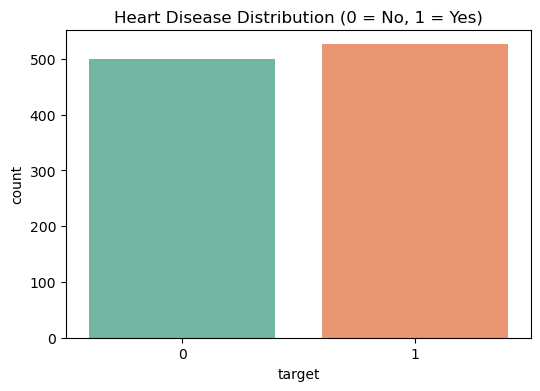

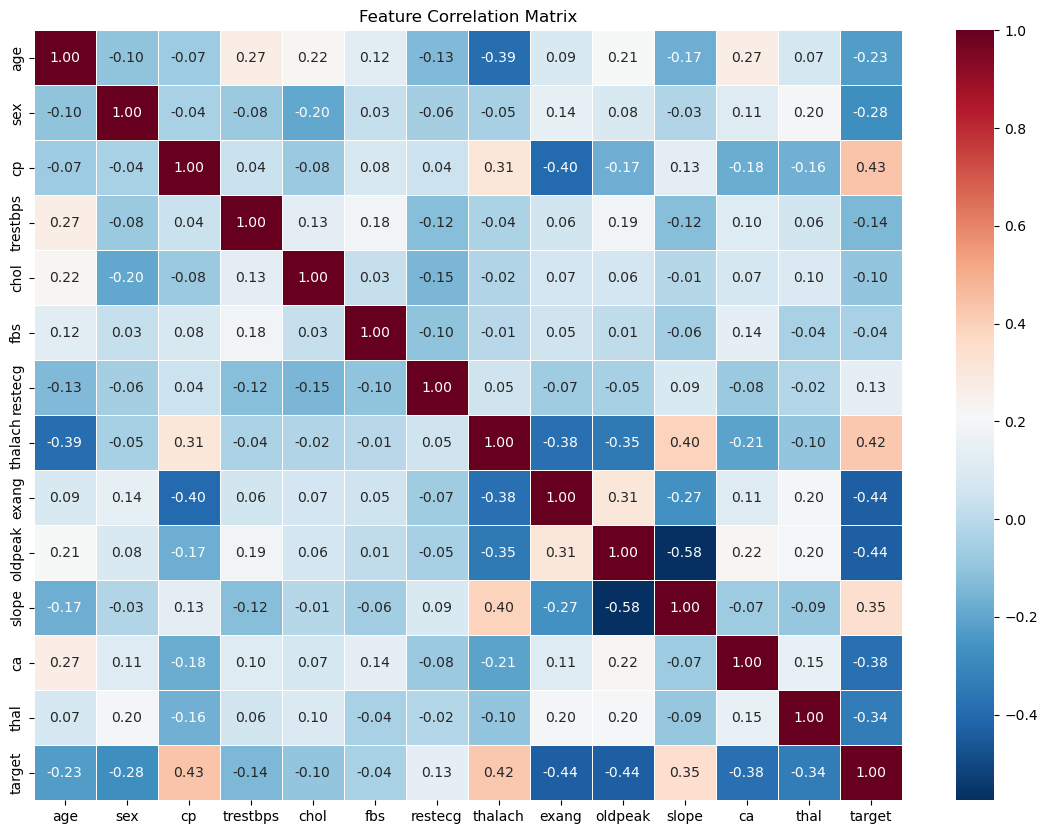

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据 (请将 'heart.csv' 替换为你实际下载的文件路径)
df = pd.read_csv('heart.csv')

# 2. 查看数据概况
display(df.head())
print(df.info())
print(df.describe())

# 3. 检查缺失值
print("\n缺失值统计:\n", df.isnull().sum())

# 4. 目标变量分布可视化
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.show()

# 5. 特征相关性热力图
# 分析特征矩阵的相关性，寻找对目标变量影响最大的生理特征
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 分离特征 (X) 和标签 (y)
X = df.drop('target', axis=1)
y = df['target']

# 划分训练集和测试集 (80% 用于训练，20% 用于测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 特征标准化 (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# 注意：测试集只能使用训练集拟合的参数进行转换，防止数据穿越
X_test_scaled = scaler.transform(X_test)

=== Logistic Regression ===
Accuracy: 0.8098
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



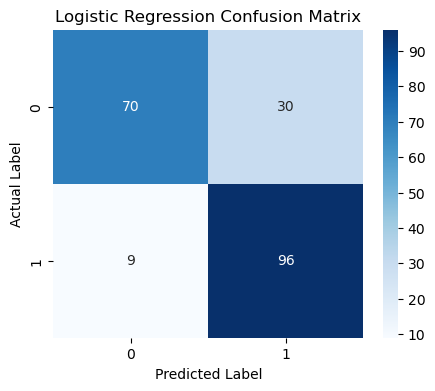

=== Support Vector Machine ===
Accuracy: 0.9268
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



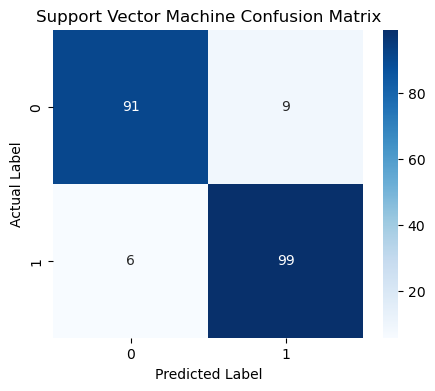

=== Random Forest ===
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



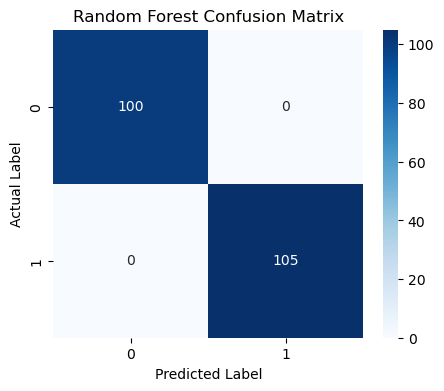

C:\Users\28947\AppData\Local\Temp\ipykernel_24584\24802655.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


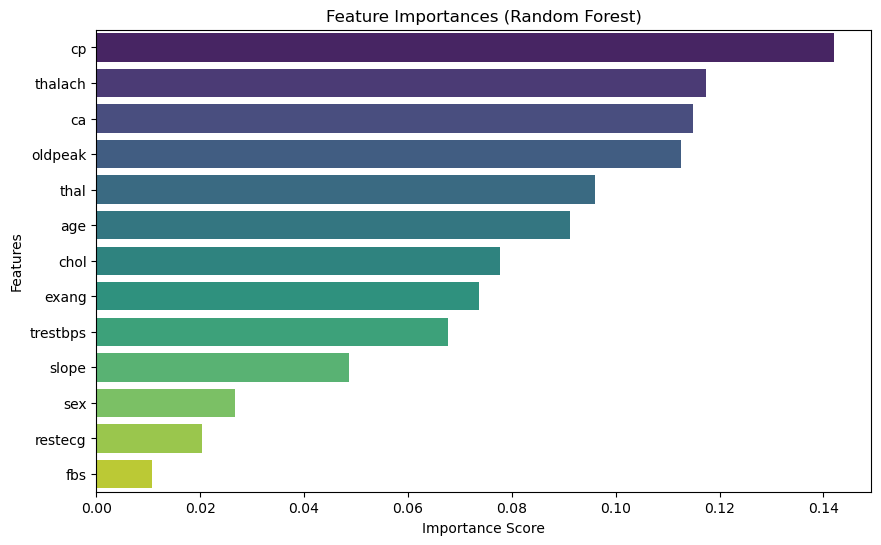

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 定义一个字典来存储模型结果，方便最后比较
model_results = {}

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    """训练模型并输出评估报告和混淆矩阵"""
    # 训练模型
    model.fit(X_train, y_train)
    # 预测
    y_pred = model.predict(X_test)
    
    # 计算准确率并存入字典
    acc = accuracy_score(y_test, y_pred)
    model_results[model_name] = acc
    
    print(f"=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # 绘制混淆矩阵
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ---------------------------------------------------------
# 模型 1：逻辑回归 (Logistic Regression)
# ---------------------------------------------------------
lr_model = LogisticRegression(random_state=42)
evaluate_model("Logistic Regression", lr_model, X_train_scaled, y_train, X_test_scaled, y_test)

# ---------------------------------------------------------
# 模型 2：支持向量机 (SVM)
# ---------------------------------------------------------
# 使用 RBF 核函数处理非线性关系
svm_model = SVC(kernel='rbf', random_state=42)
evaluate_model("Support Vector Machine", svm_model, X_train_scaled, y_train, X_test_scaled, y_test)

# ---------------------------------------------------------
# 模型 3：随机森林 (Random Forest)
# ---------------------------------------------------------
# 树模型对数据缩放不敏感，但为了流程统一，这里仍使用 scaled 数据
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model("Random Forest", rf_model, X_train_scaled, y_train, X_test_scaled, y_test)

# 提取随机森林的特征重要性 
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()